In [3]:
# 睡眠と健康の分析

import pandas as pd
import matplotlib.pyplot as plt

path = r"C:\Users\spax2\Documents\PythonWork\ExcelDATA\健康_睡眠_統合データ.xlsx"
df = pd.read_excel(path)

# 1) 日付処理
df["日付"] = pd.to_datetime(df["日付"])
df = df.sort_values("日付").reset_index(drop=True)

# 2) 派生指標
df["睡眠総分"] = df["深い睡眠（分）"] + df["レム睡眠（分）"] + df["浅い睡眠（分）"]
df["深い比率"] = df["深い睡眠（分）"] / df["睡眠総分"]
df["レム比率"] = df["レム睡眠（分）"] / df["睡眠総分"]

# 前日ラグ（前夜の睡眠 → 翌朝の健康指標を見るため）
df["睡眠時間_前日"] = df["睡眠時間（時間）"].shift(1)
df["睡眠スコア_前日"] = df["睡眠スコア（自作）"].shift(1)
df["深い比率_前日"] = df["深い比率"].shift(1)

# 週平均（移動平均でもOK）
df["血糖_7日平均"] = df["血糖値"].rolling(7).mean()
df["睡眠_7日平均"] = df["睡眠時間（時間）"].rolling(7).mean()

print(df.head())
print("欠損数\n", df.isna().sum())


          日付    体重    血糖値  血圧収縮期  血圧拡張期   心拍数  中程度運動量（分）  運動消費カロリー     歩数  \
0 2025-02-01  71.4  101.0  130.0   76.0  51.0          0        41   2121   
1 2025-02-02  71.8  124.0  126.0   67.0  52.0          5        77   4377   
2 2025-02-03  71.9  118.0  141.0   71.0  50.0         93       412  11351   
3 2025-02-04  72.0  109.0  132.0   72.0  54.0        209       469  12377   
4 2025-02-05  71.8  120.0  144.0   86.0  57.0         87       363   9753   

   睡眠時間（時間）  ...  HA1c  前60日平均血糖値   睡眠総分      深い比率      レム比率  睡眠時間_前日  \
0       8.1  ...   6.9      125.7  487.0  0.170431  0.275154      NaN   
1       7.2  ...   6.9      125.7  430.0  0.000000  0.267442      8.1   
2       7.5  ...   6.9      125.7  450.0  0.006667  0.315556      7.2   
3       9.3  ...   6.9      125.7  558.0  0.053763  0.263441      7.5   
4       6.6  ...   6.9      125.7  394.0  0.124365  0.347716      9.3   

   睡眠スコア_前日   深い比率_前日  血糖_7日平均  睡眠_7日平均  
0       NaN       NaN      NaN      NaN  
1      89.7  0

In [4]:
#日本語を表記できるようにする # matplotlibで日本語を使う。font.familyを変更する 
import matplotlib 
from matplotlib import pyplot as plt 
plt.rcParams['font.family'] = 'HGMinchoB'

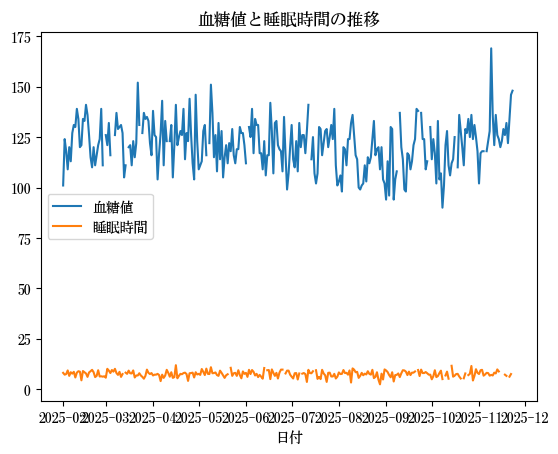

In [5]:
# 1. まず見るべきグラフ（折れ線重ね）

plt.figure()
plt.plot(df["日付"], df["血糖値"], label="血糖値")
plt.plot(df["日付"], df["睡眠時間（時間）"], label="睡眠時間")
plt.legend()
plt.title("血糖値と睡眠時間の推移")
plt.xlabel("日付")
plt.show()


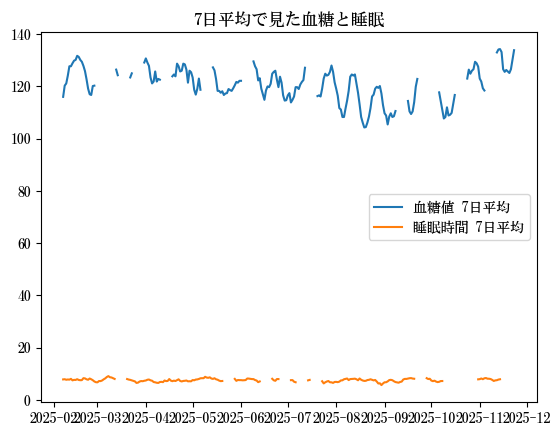

In [6]:
# コツ  7日平均も重ねるとトレンドが見やすいです。

plt.figure()
plt.plot(df["日付"], df["血糖_7日平均"], label="血糖値 7日平均")
plt.plot(df["日付"], df["睡眠_7日平均"], label="睡眠時間 7日平均")
plt.legend()
plt.title("7日平均で見た血糖と睡眠")
plt.show()


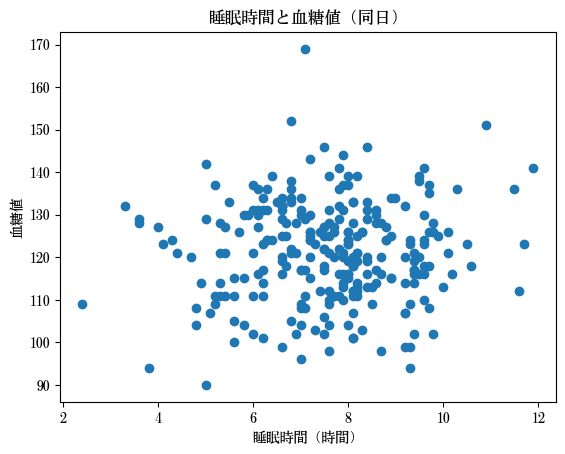

In [7]:
# 2. 散布図（関係があるか一発でわかる）
#    同日
plt.figure()
plt.scatter(df["睡眠時間（時間）"], df["血糖値"])
plt.title("睡眠時間と血糖値（同日）")
plt.xlabel("睡眠時間（時間）")
plt.ylabel("血糖値")
plt.show()


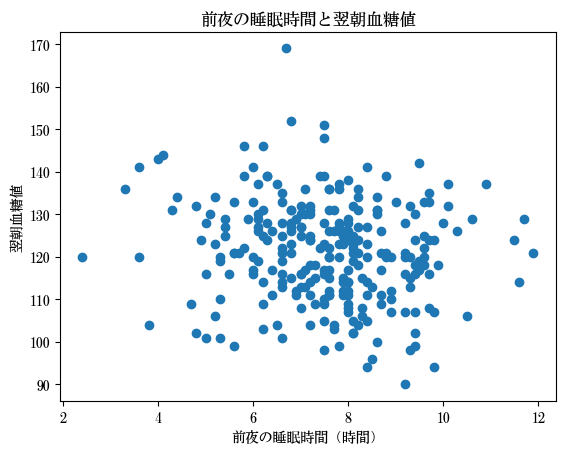

In [8]:
# 前日ラグ（前夜の睡眠 → 翌朝血糖）

plt.figure()
plt.scatter(df["睡眠時間_前日"], df["血糖値"])
plt.title("前夜の睡眠時間と翌朝血糖値")
plt.xlabel("前夜の睡眠時間（時間）")
plt.ylabel("翌朝血糖値")
plt.show()


In [9]:
# 3. 相関を数値で出す

cols = [
    "血糖値","体重","血圧収縮期","血圧拡張期","心拍数",
    "睡眠時間（時間）","睡眠スコア（自作）","深い比率","レム比率",
    "中程度運動量（分）","歩数","運動消費カロリー"
]
corr = df[cols].corr()
print(corr[["血糖値"]].sort_values("血糖値", ascending=False))


                血糖値
血糖値        1.000000
レム比率       0.130344
血圧拡張期      0.118721
歩数         0.101716
心拍数        0.089556
血圧収縮期      0.075123
睡眠時間（時間）   0.045300
体重         0.025528
睡眠スコア（自作）  0.016928
中程度運動量（分） -0.064918
運動消費カロリー  -0.080982
深い比率      -0.094477


In [ ]:
# 多変量回帰分析

pip install statsmodels


   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ------------------------- -------------- 6.0/9.6 MB 30.7 MB/s eta 0:00:01
   ----------------------------------- ---- 8.7/9.6 MB 24.4 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 18.8 MB/s  0:00:00
   ---------------------------------------- 0.0/38.7 MB ? eta -:--:--
   ------- -------------------------------- 7.6/38.7 MB 36.2 MB/s eta 0:00:01
   -------------- ------------------------- 13.6/38.7 MB 34.2 MB/s eta 0:00:01
   ------------------- -------------------- 19.1/38.7 MB 30.9 MB/s eta 0:00:01
   ------------------------- -------------- 24.9/38.7 MB 30.3 MB/s eta 0:00:01
   -------------------------------- ------- 31.2/38.7 MB 30.0 MB/s eta 0:00:01
   -------------------------------------- - 37.2/38.7 MB 29.9 MB/s eta 0:00:01
   ---------------------------------------- 38.7/38.7 MB 28.3 MB/s  0:00:01

   ---------------------------------------- 0/3 [scipy]
   ------------------------

In [9]:
# 4. “睡眠＋運動＋体重”で血糖を説明する簡単回帰

import statsmodels.api as sm

use = df[[
    "血糖値",
    "睡眠時間_前日",
    "深い比率_前日",
    "中程度運動量（分）",
    "歩数",
    "体重"
]].dropna()

X = use[["睡眠時間_前日","深い比率_前日","中程度運動量（分）","歩数","体重"]]
y = use["血糖値"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                    血糖値   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     2.816
Date:                Tue, 25 Nov 2025   Prob (F-statistic):             0.0170
Time:                        15:38:56   Log-Likelihood:                -1031.3
No. Observations:                 267   AIC:                             2075.
Df Residuals:                     261   BIC:                             2096.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        131.9809     89.017      1.483      0.1

カテゴリ別平均血糖値：
睡眠カテゴリ_前日
短い(～6時間)       123.404762
普通(6～7.5時間)    123.488095
長い(7.5時間～)     119.404255
Name: 血糖値, dtype: float64


C:\Users\spax2\AppData\Local\Temp\ipykernel_37776\2651637056.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_means = df.groupby("睡眠カテゴリ_前日")["血糖値"].mean().reindex(labels)


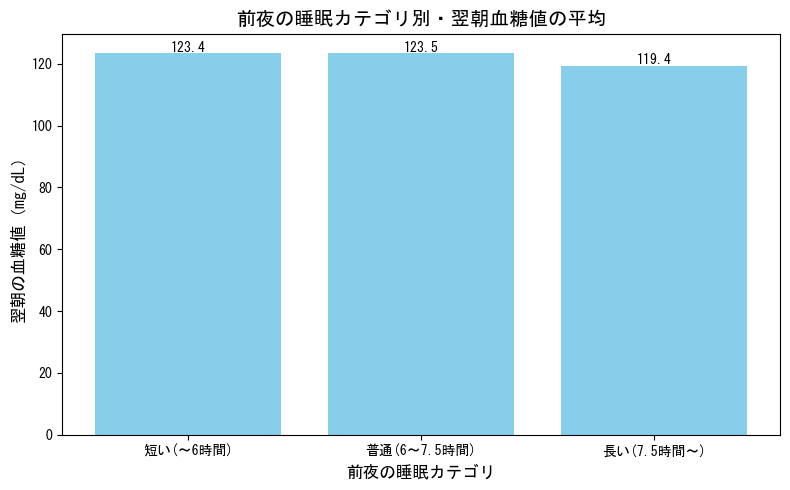

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ★ 日本語フォント設定（あなたのPC用：MS Gothic）
plt.rcParams["font.family"] = "MS Gothic"
plt.rcParams["axes.unicode_minus"] = False

# === データ読み込み ===
path = r"C:\Users\spax2\Documents\PythonWork\ExcelDATA\健康_睡眠_統合データ.xlsx"
df = pd.read_excel(path)

df["日付"] = pd.to_datetime(df["日付"])
df = df.sort_values("日付").reset_index(drop=True)

# === 1日前の睡眠データを使う（翌朝血糖を予測するため） ===
df["睡眠時間_前日"] = df["睡眠時間（時間）"].shift(1)

# === 睡眠カテゴリを作成 ===
bins = [-np.inf, 6.0, 7.5, np.inf]
labels = ["短い(～6時間)", "普通(6～7.5時間)", "長い(7.5時間～)"]

df["睡眠カテゴリ_前日"] = pd.cut(df["睡眠時間_前日"], bins=bins, labels=labels)

# === 各カテゴリの翌朝血糖の平均 ===
cat_means = df.groupby("睡眠カテゴリ_前日")["血糖値"].mean().reindex(labels)

print("カテゴリ別平均血糖値：")
print(cat_means)

# === グラフ作成 ===
plt.figure(figsize=(8, 5))
plt.bar(cat_means.index.astype(str), cat_means.values, color=("skyblue"))
plt.title("前夜の睡眠カテゴリ別・翌朝血糖値の平均", fontsize=14)
plt.xlabel("前夜の睡眠カテゴリ", fontsize=12)
plt.ylabel("翌朝の血糖値（mg/dL）", fontsize=12)

# 棒の上に数値を表示
for idx, value in enumerate(cat_means.values):
    plt.text(idx, value + 0.5, f"{value:.1f}", ha="center")

plt.tight_layout()
plt.show()



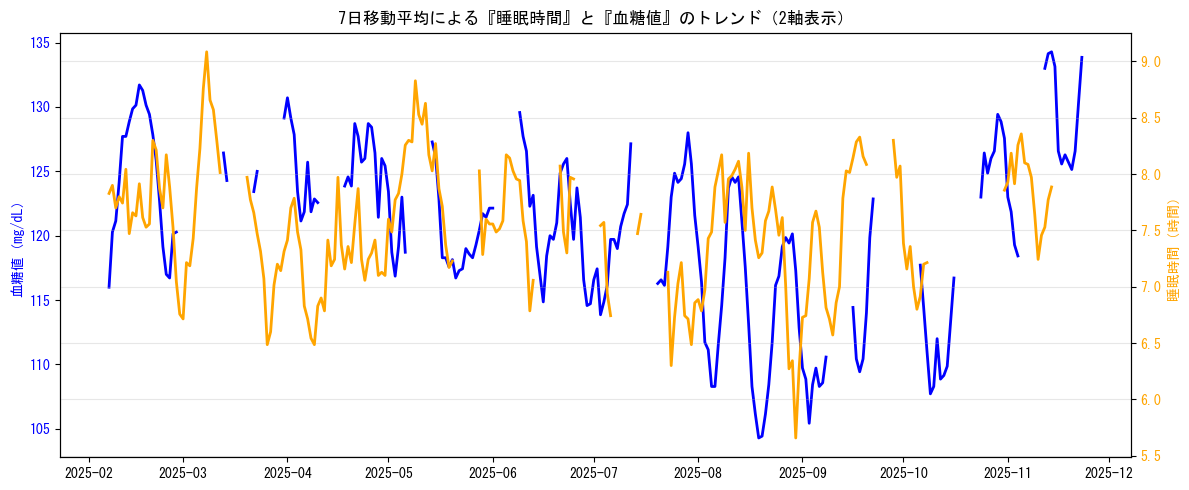

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 日本語フォント設定
plt.rcParams["font.family"] = "MS Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ===== データ読み込み =====
df = pd.read_excel(r"C:\Users\spax2\Documents\PythonWork\ExcelDATA\健康_睡眠_統合データ.xlsx")

df["日付"] = pd.to_datetime(df["日付"])
df = df.sort_values("日付").reset_index(drop=True)

# ===== 7日移動平均 =====
df["血糖_7日平均"] = df["血糖値"].rolling(7).mean()
df["睡眠_7日平均"] = df["睡眠時間（時間）"].rolling(7).mean()

# ===== 2軸グラフ =====
fig, ax1 = plt.subplots(figsize=(12,5))

# --- 左軸：血糖値 ---
ax1.plot(df["日付"], df["血糖_7日平均"], color="blue", linewidth=2, label="血糖値（7日平均）")
ax1.set_ylabel("血糖値（mg/dL）", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")

# --- 右軸：睡眠 ---
ax2 = ax1.twinx()
ax2.plot(df["日付"], df["睡眠_7日平均"], color="orange", linewidth=2, label="睡眠時間（7日平均）")
ax2.set_ylabel("睡眠時間（時間）", color="orange")
ax2.tick_params(axis='y', labelcolor="orange")

# --- タイトル・補助 ---
plt.title("7日移動平均による『睡眠時間』と『血糖値』のトレンド（2軸表示）")
fig.tight_layout()
plt.grid(alpha=0.3)
plt.show()



分類件数：
 群
睡眠多/運動多    74
睡眠多/運動少    67
睡眠少/運動多    61
睡眠少/運動少    65
Name: count, dtype: int64

各群の平均血糖：
 群
睡眠多/運動多    120.054054
睡眠多/運動少    118.686567
睡眠少/運動多    122.442623
睡眠少/運動少    124.415385
Name: 血糖値, dtype: float64


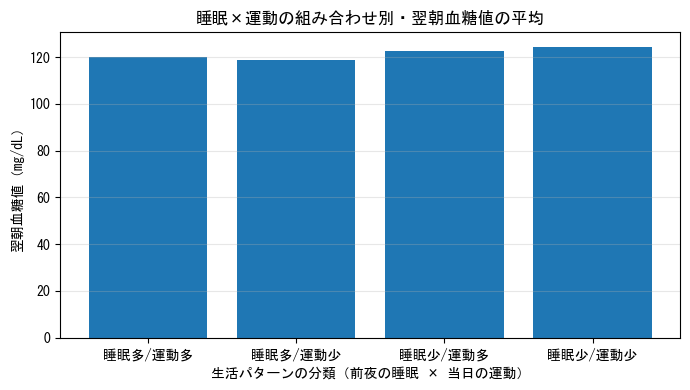

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 日本語フォント設定
plt.rcParams["font.family"] = "MS Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ===== データ読み込み =====
df = pd.read_excel(r"C:\Users\spax2\Documents\PythonWork\ExcelDATA\健康_睡眠_統合データ.xlsx")

df["日付"] = pd.to_datetime(df["日付"])
df = df.sort_values("日付").reset_index(drop=True)

# ===== 前日の睡眠時間 =====
df["睡眠時間_前日"] = df["睡眠時間（時間）"].shift(1)

# ===== データの抽出 =====
analysis_df = df[["睡眠時間_前日", "中程度運動量（分）", "血糖値"]].dropna().copy()

# 中央値で多い／少ないを分類
sleep_med = analysis_df["睡眠時間_前日"].median()
ex_med = analysis_df["中程度運動量（分）"].median()

analysis_df["睡眠高低"] = np.where(analysis_df["睡眠時間_前日"] >= sleep_med, "睡眠多", "睡眠少")
analysis_df["運動高低"] = np.where(analysis_df["中程度運動量（分）"] >= ex_med, "運動多", "運動少")

# 4群分類
analysis_df["群"] = analysis_df["睡眠高低"] + "/" + analysis_df["運動高低"]

# ===== 群ごとの平均血糖 =====
group_means = analysis_df.groupby("群")["血糖値"].mean().reindex(
    ["睡眠多/運動多", "睡眠多/運動少", "睡眠少/運動多", "睡眠少/運動少"]
)

group_counts = analysis_df["群"].value_counts().reindex(group_means.index)

print("分類件数：\n", group_counts)
print("\n各群の平均血糖：\n", group_means)

# ===== 棒グラフ =====
plt.figure(figsize=(7,4))
plt.bar(group_means.index, group_means.values)
plt.title("睡眠×運動の組み合わせ別・翌朝血糖値の平均")
plt.xlabel("生活パターンの分類（前夜の睡眠 × 当日の運動）")
plt.ylabel("翌朝血糖値（mg/dL）")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


分類件数：
 群
睡眠多/運動多    74
睡眠多/運動少    67
睡眠少/運動多    61
睡眠少/運動少    65
Name: count, dtype: int64

各群の平均血糖：
 群
睡眠多/運動多    120.054054
睡眠多/運動少    118.686567
睡眠少/運動多    122.442623
睡眠少/運動少    124.415385
Name: 血糖値, dtype: float64


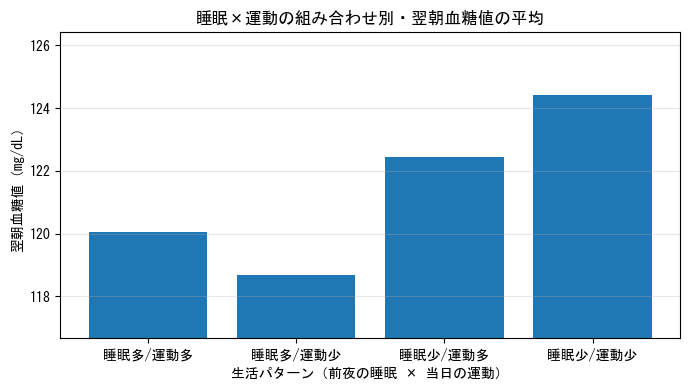

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 日本語フォント設定
plt.rcParams["font.family"] = "MS Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ===== データ読み込み =====
df = pd.read_excel(r"C:\Users\spax2\Documents\PythonWork\ExcelDATA\健康_睡眠_統合データ.xlsx")

df["日付"] = pd.to_datetime(df["日付"])
df = df.sort_values("日付").reset_index(drop=True)

# ===== 前日の睡眠時間 =====
df["睡眠時間_前日"] = df["睡眠時間（時間）"].shift(1)

# ===== データの抽出 =====
analysis_df = df[["睡眠時間_前日", "中程度運動量（分）", "血糖値"]].dropna().copy()

# 中央値で多い／少ないを分類
sleep_med = analysis_df["睡眠時間_前日"].median()
ex_med = analysis_df["中程度運動量（分）"].median()

analysis_df["睡眠高低"] = np.where(analysis_df["睡眠時間_前日"] >= sleep_med, "睡眠多", "睡眠少")
analysis_df["運動高低"] = np.where(analysis_df["中程度運動量（分）"] >= ex_med, "運動多", "運動少")

# 4群分類
analysis_df["群"] = analysis_df["睡眠高低"] + "/" + analysis_df["運動高低"]

# ===== 群ごとの平均血糖 =====
group_means = analysis_df.groupby("群")["血糖値"].mean().reindex(
    ["睡眠多/運動多", "睡眠多/運動少", "睡眠少/運動多", "睡眠少/運動少"]
)

group_counts = analysis_df["群"].value_counts().reindex(group_means.index)

print("分類件数：\n", group_counts)
print("\n各群の平均血糖：\n", group_means)

# ===== 棒グラフ =====
plt.figure(figsize=(7,4))
plt.bar(group_means.index, group_means.values)

# ★ Y軸を切り取って差をわかりやすくする
ymin = group_means.min() - 2   # 少しだけ下げる
plt.ylim(ymin, group_means.max() + 2)

plt.title("睡眠×運動の組み合わせ別・翌朝血糖値の平均")
plt.xlabel("生活パターン（前夜の睡眠 × 当日の運動）")
plt.ylabel("翌朝血糖値（mg/dL）")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [18]:
import pandas as pd
import numpy as np

# ===== ファイルパス =====
統合データ = r"C:\Users\spax2\Documents\PythonWork\ExcelDATA\健康_睡眠_統合データ.xlsx"
HA1cファイル = r"C:\Users\spax2\Documents\PythonWork\ExcelDATA\データ表4.xlsx"

# ===== 1) データ読み込み =====
df = pd.read_excel(統合データ)
hba1c_df = pd.read_excel(HA1cファイル, sheet_name="Sheet2")

df["日付"] = pd.to_datetime(df["日付"])
hba1c_df["日付"] = pd.to_datetime(hba1c_df["日付"])

# ===== 2) 昇順ソート =====
df = df.sort_values("日付").reset_index(drop=True)
hba1c_df = hba1c_df.sort_values("日付").reset_index(drop=True)

# ===== 3) 分析用：睡眠比率（念のため） =====
df["睡眠総分"] = df["深い睡眠（分）"] + df["レム睡眠（分）"] + df["浅い睡眠（分）"]
df["深い比率"] = df["深い睡眠（分）"] / df["睡眠総分"]

# ===== 4) 測定日前60日の平均値を計算 =====
records = []

for _, row in hba1c_df.iterrows():
    meas_date = row["日付"]
    start_date = meas_date - pd.Timedelta(days=60)

    # 測定日前60日のデータを抽出
    window = df[(df["日付"] > start_date) & (df["日付"] <= meas_date)]

    rec = {
        "測定日": meas_date.date(),
        "HA1c": row["HA1c"],
        "前60日平均血糖値（シート値）": row["前60日平均血糖値"],
        "前60日平均血糖値（再計算）": window["血糖値"].mean(),
        "前60日平均睡眠時間（時間）": window["睡眠時間（時間）"].mean(),
        "前60日平均深い比率": window["深い比率"].mean(),
        "前60日平均中程度運動（分）": window["中程度運動量（分）"].mean(),
        "前60日平均歩数": window["歩数"].mean()
    }

    records.append(rec)

結果df = pd.DataFrame(records)

# ===== 5) Excelに書き出し =====
out_path = r"C:\Users\spax2\Documents\PythonWork\ExcelDATA\HA1c_60日分析.xlsx"
結果df.to_excel(out_path, index=False)

print("分析完了：", out_path)
print(結果df)


分析完了： C:\Users\spax2\Documents\PythonWork\ExcelDATA\HA1c_60日分析.xlsx
           測定日  HA1c  前60日平均血糖値（シート値）  前60日平均血糖値（再計算）  前60日平均睡眠時間（時間）  \
0   2022-02-03   6.5            119.1             NaN             NaN   
1   2022-04-07   6.3            116.5             NaN             NaN   
2   2022-06-09   6.3            112.9             NaN             NaN   
3   2022-08-04   6.3            111.2             NaN             NaN   
4   2022-10-06   6.3            112.0             NaN             NaN   
5   2022-12-08   6.6            117.5             NaN             NaN   
6   2023-02-02   6.5            119.4             NaN             NaN   
7   2023-04-06   6.7            125.6             NaN             NaN   
8   2023-06-08   6.6            123.3             NaN             NaN   
9   2023-08-03   7.0            129.1             NaN             NaN   
10  2023-10-12   6.4            115.9             NaN             NaN   
11  2024-02-08   7.1            134.6             NaN   

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===== 日本語フォント設定 =====
plt.rcParams["font.family"] = "MS Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ===== 統合データ読み込み =====
path = r"C:\Users\spax2\Documents\PythonWork\ExcelDATA\健康_睡眠_統合データ.xlsx"
df = pd.read_excel(path)

df["日付"] = pd.to_datetime(df["日付"])
df = df.sort_values("日付").reset_index(drop=True)

# HA1c・前60日平均血糖値が無い行は分析対象外
if "HA1c" not in df.columns or "前60日平均血糖値" not in df.columns:
    raise ValueError("統合ファイルに『HA1c』『前60日平均血糖値』列が見つかりません。")

# ===== 1) HA1c測定日を推定する =====
# merge_asof で埋めたため、HA1cは測定日以降しばらく同じ値が続く。
# 『値が変わった日』または『最初に出てくる日』を測定日とみなす。
h = df[df["HA1c"].notna()][["日付", "HA1c", "前60日平均血糖値"]].copy()
h = h.sort_values("日付").reset_index(drop=True)

h["HA1c_prev"] = h["HA1c"].shift(1)
h["avg_prev"] = h["前60日平均血糖値"].shift(1)

# ・最初の1行
# ・HA1cが前日と違う
# ・前60日平均血糖値が前日と違う
is_measure = (
    h.index == 0
) | (h["HA1c"] != h["HA1c_prev"]) | (h["前60日平均血糖値"] != h["avg_prev"])

meas = h[is_measure].copy().reset_index(drop=True)

print("推定されたHA1c測定日一覧：")
print(meas[["日付", "HA1c", "前60日平均血糖値"]])

# ===== 2) 各測定日の「直前60日」窓の集計 =====
records = []

for _, row in meas.iterrows():
    meas_date = row["日付"]

    # 60日前の開始日
    window_start = meas_date - pd.Timedelta(days=60)

    # ★windowの定義：
    #   「測定日の60日前までの朝食前血糖値の平均」と説明があったので
    #   [測定日-60日, 測定日前日] を対象にする
    mask = (df["日付"] >= window_start) & (df["日付"] < meas_date)
    w = df[mask]

    rec = {
        "測定日": meas_date.date(),
        "HA1c": row["HA1c"],
        "前60日平均血糖値（元シート値）": row["前60日平均血糖値"],
        "前60日平均血糖値（再計算）": w["血糖値"].mean(),
        "前60日平均_睡眠時間": w["睡眠時間（時間）"].mean(),
        "前60日平均_深い比率": w["深い比率"].mean(),
        "前60日平均_中程度運動量": w["中程度運動量（分）"].mean(),
        "前60日平均_歩数": w["歩数"].mean(),
        "サンプル日数": len(w),
    }
    records.append(rec)

summary = pd.DataFrame(records)
print("\nHA1cごとの直前60日集計：")
print(summary)

# ===== 3) 結果をExcelに保存 =====
out_path = r"C:\Users\spax2\Documents\PythonWork\ExcelDATA\HA1c_60日前分析.xlsx"
summary.to_excel(out_path, index=False)
print("\n✅ 解析結果を保存しました：", out_path)

# ===== 4) ざっくり関係を見る散布図 =====

# HA1c vs 前60日平均血糖値（再計算）
plt.figure()
plt.scatter(summary["前60日平均血糖値（再計算）"], summary["HA1c"])
plt.xlabel("前60日平均血糖値（再計算）")
plt.ylabel("HA1c")
plt.title("HA1c と 前60日平均血糖値の関係")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# HA1c vs 前60日平均睡眠時間
plt.figure()
plt.scatter(summary["前60日平均_睡眠時間"], summary["HA1c"])
plt.xlabel("前60日平均 睡眠時間（時間）")
plt.ylabel("HA1c")
plt.title("HA1c と 前60日平均睡眠時間の関係")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# HA1c vs 前60日平均中程度運動
plt.figure()
plt.scatter(summary["前60日平均_中程度運動量"], summary["HA1c"])
plt.xlabel("前60日平均 中程度運動量（分）")
plt.ylabel("HA1c")
plt.title("HA1c と 前60日平均 中程度運動の関係")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [21]:
import pandas as pd

# ==== HA1c 測定データ ====
hba_path = r"C:\Users\spax2\Documents\PythonWork\ExcelDATA\データ表4.xlsx"
hba = pd.read_excel(hba_path, sheet_name="Sheet2")

hba["日付"] = pd.to_datetime(hba["日付"])
hba = hba.sort_values("日付").reset_index(drop=True)

print(hba)


           日付  HA1c  前60日平均血糖値
0  2022-02-03   6.5      119.1
1  2022-04-07   6.3      116.5
2  2022-06-09   6.3      112.9
3  2022-08-04   6.3      111.2
4  2022-10-06   6.3      112.0
5  2022-12-08   6.6      117.5
6  2023-02-02   6.5      119.4
7  2023-04-06   6.7      125.6
8  2023-06-08   6.6      123.3
9  2023-08-03   7.0      129.1
10 2023-10-12   6.4      115.9
11 2024-02-08   7.1      134.6
12 2024-04-04   6.8      129.1
13 2024-06-04   7.0      135.8
14 2024-08-08   7.3      130.8
15 2024-10-03   6.7      109.8
16 2024-11-05   6.6      108.6
17 2025-01-07   6.7      124.0
18 2025-01-27   6.9      125.7
19 2025-04-01   6.8      124.1
20 2025-07-01   6.6      121.3
21 2025-09-22   6.5      115.1


In [22]:
merge_path = r"C:\Users\spax2\Documents\PythonWork\ExcelDATA\健康_睡眠_統合データ.xlsx"
df = pd.read_excel(merge_path)

df["日付"] = pd.to_datetime(df["日付"])
df = df.sort_values("日付").reset_index(drop=True)


In [23]:
records = []

for _, row in hba.iterrows():

    measure_date = row["日付"]
    window_start = measure_date - pd.Timedelta(days=60)

    # 測定日前60日を抽出
    win = df[(df["日付"] > window_start) & (df["日付"] <= measure_date)]

    rec = {
        "測定日": measure_date.date(),
        "HA1c": row["HA1c"],
        "前60日平均血糖値": win["血糖値"].mean(),
        "前60日平均睡眠時間": win["睡眠時間（時間）"].mean(),
        "前60日平均深い比率": win["深い睡眠（分）"].sum() / win["睡眠総分"].sum() if win["睡眠総分"].sum() > 0 else None,
        "前60日平均中程度運動": win["中程度運動量（分）"].mean(),
        "前60日平均歩数": win["歩数"].mean(),
        "前60日平均体重": win["体重"].mean(),
    }

    records.append(rec)

result = pd.DataFrame(records)
print(result)


KeyError: '睡眠総分'

In [24]:
import pandas as pd
from datetime import timedelta

# ===== ファイル読み込み =====
hba_path = r"C:\Users\spax2\Documents\PythonWork\ExcelDATA\データ表4.xlsx"
integrated_path = r"C:\Users\spax2\Documents\PythonWork\ExcelDATA\健康_睡眠_統合データ.xlsx"

# HA1cデータ
hba = pd.read_excel(hba_path, sheet_name="Sheet2")
hba["日付"] = pd.to_datetime(hba["日付"])

# 統合データ
df = pd.read_excel(integrated_path)
df["日付"] = pd.to_datetime(df["日付"])
df = df.sort_values("日付")

# ===== ここが重要：睡眠総分を作成 =====
df["睡眠総分"] = (
    df["深い睡眠（分）"].fillna(0)
    + df["レム睡眠（分）"].fillna(0)
    + df["浅い睡眠（分）"].fillna(0)
)

# ===== 測定日前60日を集計 =====
records = []

for _, row in hba.iterrows():
    measure_date = row["日付"]
    window_start = measure_date - timedelta(days=60)

    win = df[(df["日付"] > window_start) & (df["日付"] <= measure_date)]

    if len(win) > 0:
        deep_ratio = (
            win["深い睡眠（分）"].sum() / win["睡眠総分"].sum()
            if win["睡眠総分"].sum() > 0 else None
        )
    else:
        deep_ratio = None

    rec = {
        "測定日": measure_date.date(),
        "HA1c": row["HA1c"],
        "前60日平均血糖値": win["血糖値"].mean(),
        "前60日平均睡眠時間": win["睡眠時間（時間）"].mean(),
        "前60日深い比率": deep_ratio,
        "前60日平均中程度運動": win["中程度運動量（分）"].mean(),
        "前60日平均歩数": win["歩数"].mean(),
        "前60日平均体重": win["体重"].mean(),
    }
    records.append(rec)

result = pd.DataFrame(records)

# ===== 保存 =====
out_path = r"C:\Users\spax2\Documents\PythonWork\ExcelDATA\HA1c_60日分析_結果.xlsx"
result.to_excel(out_path, index=False)

print("保存しました →", out_path)


保存しました → C:\Users\spax2\Documents\PythonWork\ExcelDATA\HA1c_60日分析_結果.xlsx


In [ ]:
import pandas as pd

# --- HA1cデータの読み込み（さっきの hba を使用） ---
hba_path = "/mnt/data/データ表4.xlsx"
xls = pd.ExcelFile(hba_path)

if "Sheet2" in xls.sheet_names:
    hba = pd.read_excel(hba_path, sheet_name="Sheet2")
else:
    hba = pd.read_excel(hba_path, sheet_name=xls.sheet_names[0])

hba["日付"] = pd.to_datetime(hba["日付"])
hba = hba.sort_values("日付").reset_index(drop=True)

# --- 統合データ df（すでに読み込み済） ---
df["日付"] = pd.to_datetime(df["日付"])
df = df.sort_values("日付").reset_index(drop=True)

# 睡眠総分が無い場合に備えて作成
df["睡眠総分"] = (
    df["深い睡眠（分）"]
    + df["レム睡眠（分）"]
    + df["浅い睡眠（分）"]
)

records = []

for _, row in hba.iterrows():

    measure_date = row["日付"]
    window_start = measure_date - pd.Timedelta(days=60)

    # 測定日前60日のデータ抽出
    win = df[(df["日付"] > window_start) & (df["日付"] <= measure_date)]

    rec = {
        "測定日": measure_date.date(),
        "HA1c": row["HA1c"],
        "前60日平均血糖値（再計算）": win["血糖値"].mean(),
        "前60日平均睡眠時間": win["睡眠時間（時間）"].mean(),
        "前60日平均深い比率": (
            win["深い睡眠（分）"].sum() / win["睡眠総分"].sum()
            if win["睡眠総分"].sum() > 0 else None
        ),
        "前60日平均中程度運動": win["中程度運動量（分）"].mean(),
        "前60日平均歩数": win["歩数"].mean(),
        "前60日平均体重": win["体重"].mean(),
    }

    records.append(rec)

result = pd.DataFrame(records)
result


プロット対象件数： 3
    前60日平均睡眠時間  HA1c
19    7.693220   6.8
20    7.884211   6.6
21    7.494915   6.5


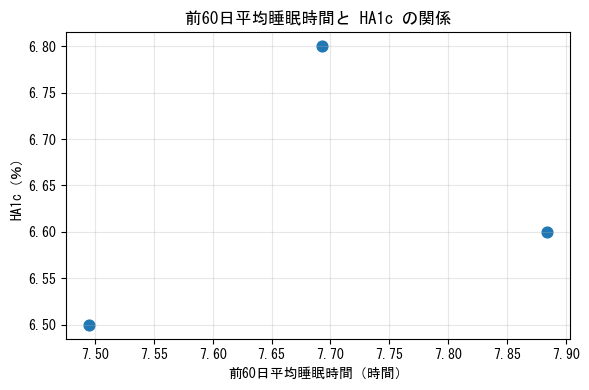

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# 日本語フォント設定（Windows）
plt.rcParams["font.family"] = "MS Gothic"  # または "Meiryo", "Yu Gothic" など
plt.rcParams["axes.unicode_minus"] = False

# ===== 1) データ読み込み =====
path = r"C:\Users\spax2\Documents\PythonWork\ExcelDATA\HA1c_60日分析_結果.xlsx"
df = pd.read_excel(path)

# 必要な列だけ取り出し（欠損は除外）
use = df[["前60日平均睡眠時間", "HA1c"]].dropna().copy()

print("プロット対象件数：", len(use))
print(use)

# ===== 2) 散布図 =====
plt.figure(figsize=(6,4))
plt.scatter(use["前60日平均睡眠時間"], use["HA1c"], s=60)

plt.xlabel("前60日平均睡眠時間（時間）")
plt.ylabel("HA1c（％）")
plt.title("前60日平均睡眠時間と HA1c の関係")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


プロット対象件数： 3
    前60日平均中程度運動  HA1c
19   179.733333   6.8
20   243.233333   6.6
21   213.583333   6.5


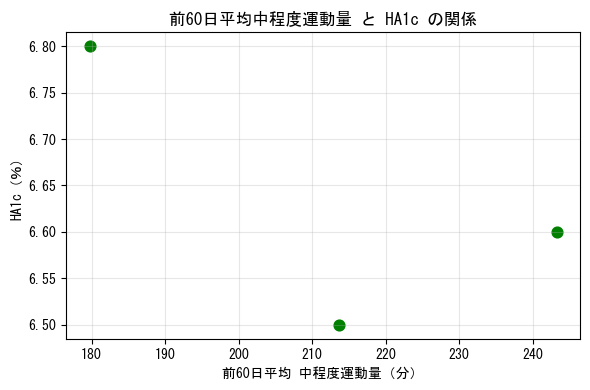

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# 日本語フォント設定（Windows）
plt.rcParams["font.family"] = "MS Gothic"   # "Meiryo" や "Yu Gothic" でもOK
plt.rcParams["axes.unicode_minus"] = False

# ===== 1) データ読み込み =====
path = r"C:\Users\spax2\Documents\PythonWork\ExcelDATA\HA1c_60日分析_結果.xlsx"
df = pd.read_excel(path)

# 必要な列だけ取り出し（欠損は除外）
use = df[["前60日平均中程度運動", "HA1c"]].dropna().copy()

print("プロット対象件数：", len(use))
print(use)

# ===== 2) 散布図 =====
plt.figure(figsize=(6,4))
plt.scatter(use["前60日平均中程度運動"], use["HA1c"], s=60, color="green")

plt.xlabel("前60日平均 中程度運動量（分）")
plt.ylabel("HA1c（％）")
plt.title("前60日平均中程度運動量 と HA1c の関係")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


プロット対象件数： 3
     前60日平均体重  HA1c
19  71.001818   6.8
20  70.584483   6.6
21  70.793220   6.5


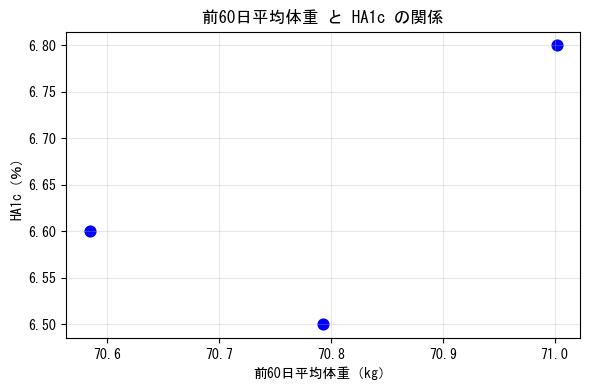

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# 日本語フォント設定（Windows）
plt.rcParams["font.family"] = "MS Gothic"   # "Meiryo" や "Yu Gothic" でもOK
plt.rcParams["axes.unicode_minus"] = False

# ===== 1) データ読み込み =====
path = r"C:\Users\spax2\Documents\PythonWork\ExcelDATA\HA1c_60日分析_結果.xlsx"
df = pd.read_excel(path)

# 必要な列だけ取り出し（欠損は除外）
use = df[["前60日平均体重", "HA1c"]].dropna().copy()

print("プロット対象件数：", len(use))
print(use)

# ===== 2) 散布図 =====
plt.figure(figsize=(6,4))
plt.scatter(use["前60日平均体重"], use["HA1c"], s=60, color="blue")

plt.xlabel("前60日平均体重（kg）")
plt.ylabel("HA1c（％）")
plt.title("前60日平均体重 と HA1c の関係")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 日本語フォント設定（Windows）
plt.rcParams["font.family"] = "MS Gothic"   # "Meiryo" や "Yu Gothic" でもOK
plt.rcParams["axes.unicode_minus"] = False

# ===== 1) データ読み込み =====
path = r"C:\Users\spax2\Documents\PythonWork\ExcelDATA\HA1c_60日分析_結果.xlsx"
df = pd.read_excel(path)

# 必要な列を取り出し（欠損は除外）
use = df[["前60日深い睡眠比率", "HA1c"]].dropna().copy()

print("プロット対象件数：", len(use))
print(use)

# ===== 2) 散布図 =====
plt.figure(figsize=(6,4))
plt.scatter(use["前60日深い睡眠比率"], use["HA1c"], s=60, color="purple")

plt.xlabel("前60日 深い睡眠比率（深い睡眠分 ÷ 総睡眠分）")
plt.ylabel("HA1c（％）")
plt.title("前60日深い睡眠比率 と HA1c の関係")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# 日本語フォント設定（Windows）
plt.rcParams["font.family"] = "MS Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ===== 1) データ読み込み =====
path = r"C:\Users\spax2\Documents\PythonWork\ExcelDATA\HA1c_60日分析_結果.xlsx"
df = pd.read_excel(path)

# 必要な列を取り出し（欠損は除外）
use = df[["前60日深い睡眠比率", "HA1c"]].dropna().copy()

print("プロット対象件数：", len(use))
print(use)

# ===== 2) 散布図 =====
plt.figure(figsize=(6,4))
plt.scatter(use["前60日深い睡眠比率"], use["HA1c"], s=60, color="purple")

plt.xlabel("前60日 深い睡眠比率（深い睡眠分 ÷ 総睡眠分）")
plt.ylabel("HA1c（％）")
plt.title("前60日深い睡眠比率 と HA1c の関係")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


KeyError: "['前60日深い睡眠比率'] not in index"

プロット対象件数： 3
    前60日深い比率  HA1c
19  0.053848   6.8
20  0.051550   6.6
21  0.031772   6.5


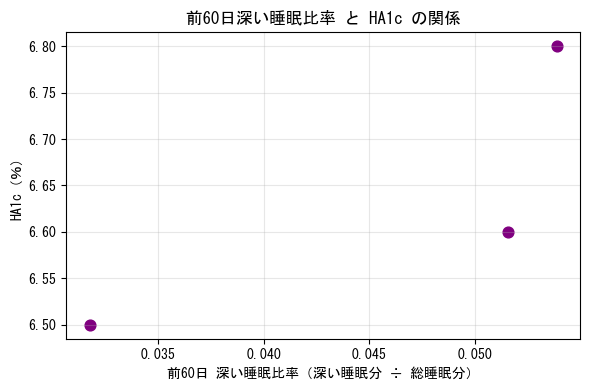

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# 日本語フォント設定（Windows）
plt.rcParams["font.family"] = "MS Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ===== 1) データ読み込み =====
path = r"C:\Users\spax2\Documents\PythonWork\ExcelDATA\HA1c_60日分析_結果.xlsx"
df = pd.read_excel(path)

# 必要な列を取り出し（欠損は除外）
use = df[["前60日深い比率", "HA1c"]].dropna().copy()

print("プロット対象件数：", len(use))
print(use)

# ===== 2) 散布図 =====
plt.figure(figsize=(6,4))
plt.scatter(use["前60日深い比率"], use["HA1c"], s=60, color="purple")

plt.xlabel("前60日 深い睡眠比率（深い睡眠分 ÷ 総睡眠分）")
plt.ylabel("HA1c（％）")
plt.title("前60日深い睡眠比率 と HA1c の関係")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


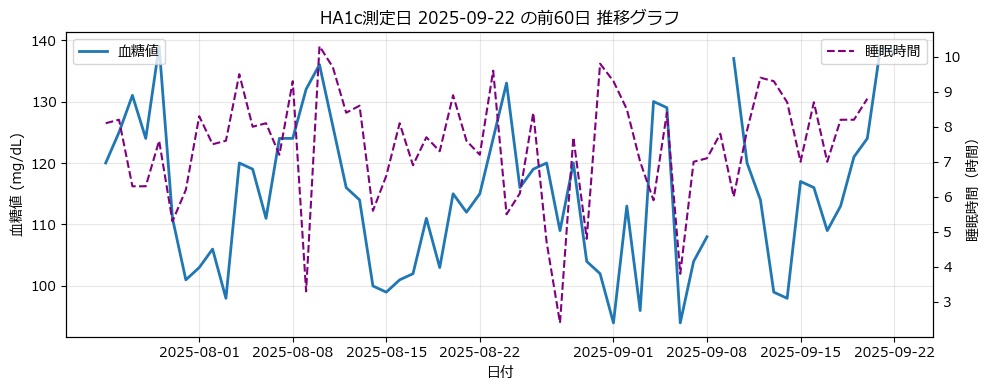

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

# 日本語フォント（Windows）
plt.rcParams["font.family"] = "Meiryo"   # ここが重要
plt.rcParams["axes.unicode_minus"] = False

# ===== データ読み込み =====
hba = pd.read_excel(r"C:\Users\spax2\Documents\PythonWork\ExcelDATA\データ表4.xlsx", sheet_name="Sheet2")
hba["日付"] = pd.to_datetime(hba["日付"])

df = pd.read_excel(r"C:\Users\spax2\Documents\PythonWork\ExcelDATA\健康_睡眠_統合データ.xlsx")
df["日付"] = pd.to_datetime(df["日付"])
df = df.sort_values("日付")

# 最新の測定日
target = hba.sort_values("日付").iloc[-1]
mdate = target["日付"]
wstart = mdate - timedelta(days=60)

# 60日間のデータ抽出
win = df[(df["日付"] > wstart) & (df["日付"] <= mdate)]

# ===== グラフ =====
fig, ax1 = plt.subplots(figsize=(10,4))

ax1.plot(win["日付"], win["血糖値"], label="血糖値", linewidth=2)
ax1.set_ylabel("血糖値 (mg/dL)")
ax1.set_xlabel("日付")
ax1.grid(alpha=0.3)
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(win["日付"], win["睡眠時間（時間）"], color="purple", label="睡眠時間", linestyle="--")
ax2.set_ylabel("睡眠時間（時間）")
ax2.legend(loc="upper right")

plt.title(f"HA1c測定日 {mdate.date()} の前60日 推移グラフ")
plt.tight_layout()
plt.show()
